In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore') 
from sklearn.preprocessing import StandardScaler,MinMaxScaler 
from sklearn.feature_selection import f_classif

In [3]:
#### loading the dataset 
df=pd.read_csv('adult_with_headers (1).csv')

In [4]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
#### missing values checking 
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [6]:
#### duplicates checking 
df.duplicated().sum()

np.int64(24)

In [7]:
#### dropping duplicates from dataset 
df.drop_duplicates(inplace=True,ignore_index=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
#### checking unique values for every features 
for col in df.columns:
    print(col)
    print(f" {df[col].unique()}")

age
 [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
workclass
 [' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
fnlwgt
 [ 77516  83311 215646 ...  34066  84661 257302]
education
 [' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
education_num
 [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
marital_status
 [' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']
occupation
 [' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Ma

In [10]:
#### replacing ? data with NAN
df=df.replace(r'^\s*\?\s*$', np.nan, regex=True)

In [11]:
#### checking unique values for every features after replacing

for col in df.columns:
    print(col)
    print(f" {df[col].unique()}")

age
 [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
workclass
 [' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 nan ' Self-emp-inc' ' Without-pay' ' Never-worked']
fnlwgt
 [ 77516  83311 215646 ...  34066  84661 257302]
education
 [' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
education_num
 [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
marital_status
 [' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']
occupation
 [' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Mac

In [12]:
### checking missing values after replacing ? 
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     582
income               0
dtype: int64

In [13]:
#### filling missing with respective 
#### this missing values are object type so fill with mode of respective feature
df.fillna({'workclass':df.workclass.mode()[0],
          'occupation':df.occupation.mode()[0],
          'native_country':df.native_country.mode()[0]},inplace=True)

In [14]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

<Axes: >

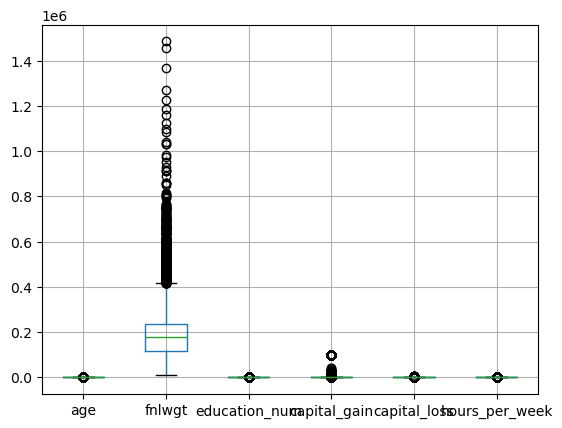

In [15]:
#### checking outliers 
df.boxplot()

In [16]:
#### removing outliers
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25) 
    Q3=df[column].quantile(0.75) 
    IQR=Q3-Q1 
    lower_extreme=Q1-1.5*IQR 
    upper_extreme=Q3+1.5*IQR 
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x> upper_extreme else x) 
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col) 

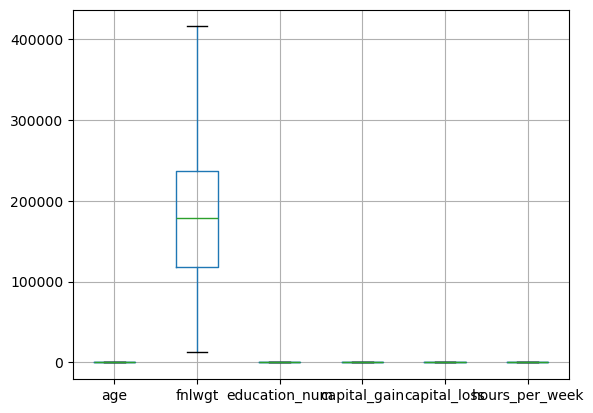

In [17]:
df.boxplot()
plt.show()

In [18]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,32.5,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [19]:
##### scaling techniques on numerical columns 
#### standard scaler 
std_sca=StandardScaler()

In [20]:
df[['age','fnlwgt','hours_per_week']]=std_sca.fit_transform(df[['age','fnlwgt','hours_per_week']])

In [21]:
std_sca_value=std_sca.fit_transform(df[['age','fnlwgt','hours_per_week']])

In [22]:
### checking Standard scalling 
std_sca_value

array([[ 0.03247191, -1.1492095 , -0.19447155],
       [ 0.8440022 , -1.08828431, -1.4066403 ],
       [-0.04130357,  0.30300728, -0.19447155],
       ...,
       [ 1.43420604, -0.36707517, -0.19447155],
       [-1.22171125,  0.1541795 , -1.4066403 ],
       [ 0.99155316,  1.06292678, -0.19447155]], shape=(32537, 3))

In [23]:
#### MinMax Scallling 
minmax_sca=MinMaxScaler()

In [24]:
minmax_sca_value=minmax_sca.fit_transform(df[['age','fnlwgt','hours_per_week']])

In [25]:
#### checking minmax scalling value
minmax_sca_value

array([[0.36065574, 0.16168018, 0.375     ],
       [0.54098361, 0.17604354, 0.        ],
       [0.3442623 , 0.50404628, 0.375     ],
       ...,
       [0.67213115, 0.34607158, 0.375     ],
       [0.08196721, 0.46895952, 0.        ],
       [0.57377049, 0.68320044, 0.375     ]], shape=(32537, 3))

In [26]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.032472,State-gov,-1.149209,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,-0.194472,United-States,<=50K
1,0.844002,Self-emp-not-inc,-1.088284,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,-1.406640,United-States,<=50K
2,-0.041304,Private,0.303007,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,-0.194472,United-States,<=50K
3,1.065329,Private,0.503550,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,-0.194472,United-States,<=50K
4,-0.779058,Private,1.593665,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,-0.194472,Cuba,<=50K


In [27]:
### convert income feature into binary format because income is target feature
df['income']=np.where(df.income=='<=50K',0,1)

In [28]:
### checking categorical columns in dataset 
for col in df.select_dtypes(['object']).columns:
    print(col)

workclass
education
marital_status
occupation
relationship
race
sex
native_country


In [29]:
for col in df.select_dtypes(include=['object']).columns:
    print(col)
    print(df[col].nunique())

workclass
8
education
16
marital_status
7
occupation
14
relationship
6
race
5
sex
2
native_country
41


In [30]:
### one-hot encoding
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder

In [31]:
one_hot_enc=OneHotEncoder()

In [32]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.032472,State-gov,-1.149209,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,-0.194472,United-States,1
1,0.844002,Self-emp-not-inc,-1.088284,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,-1.406640,United-States,1
2,-0.041304,Private,0.303007,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,-0.194472,United-States,1
3,1.065329,Private,0.503550,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,-0.194472,United-States,1
4,-0.779058,Private,1.593665,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,-0.194472,Cuba,1


In [33]:
one_hot_enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

### Fit and transform the 'sex' column
encoded = one_hot_enc.fit_transform(df[['sex']])

### Wrap into a DataFrame with proper column names
encoded_df = pd.DataFrame(encoded,
                          columns=one_hot_enc.get_feature_names_out(['sex']),
                          index=df.index)

### Concatenate with original df (dropping old 'sex')
df = pd.concat([df.drop(columns=['sex']), encoded_df], axis=1)

In [34]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Female,sex_ Male
0,0.032472,State-gov,-1.149209,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,0.0,0.0,-0.194472,United-States,1,0.0,1.0
1,0.844002,Self-emp-not-inc,-1.088284,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,0.0,0.0,-1.406640,United-States,1,0.0,1.0
2,-0.041304,Private,0.303007,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,0.0,0.0,-0.194472,United-States,1,0.0,1.0
3,1.065329,Private,0.503550,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,0.0,0.0,-0.194472,United-States,1,0.0,1.0
4,-0.779058,Private,1.593665,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,0.0,0.0,-0.194472,Cuba,1,1.0,0.0


In [35]:
#### label encoding 
cat_col=[]
for col in df.select_dtypes(include=['object']).columns :
    cat_col.append(col)
label_encoder={}
for col in cat_col:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col].astype(str)) 
    label_encoder[col]=le
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Female,sex_ Male
0,0.032472,6,-1.149209,9,13.0,4,0,1,4,0.0,0.0,-0.194472,38,1,0.0,1.0
1,0.844002,5,-1.088284,9,13.0,2,3,0,4,0.0,0.0,-1.406640,38,1,0.0,1.0
2,-0.041304,3,0.303007,11,9.0,0,5,1,4,0.0,0.0,-0.194472,38,1,0.0,1.0
3,1.065329,3,0.503550,1,7.0,2,5,0,2,0.0,0.0,-0.194472,38,1,0.0,1.0
4,-0.779058,3,1.593665,9,13.0,2,9,5,2,0.0,0.0,-0.194472,4,1,1.0,0.0


In [36]:
df.describe()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Female,sex_ Male
count,3.253700e+04,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.0,32537.0,3.253700e+04,32537.000000,32537.0,32537.000000,32537.000000
mean,1.720834e-16,3.094446,6.988157e-18,10.297507,10.125165,2.611427,6.139288,1.446538,3.665827,0.0,0.0,-2.306092e-16,36.419184,1.0,0.330762,0.669238
std,1.000015e+00,1.107549,1.000015e+00,3.870142,2.459436,1.506301,3.973173,1.607064,0.848847,0.0,0.0,1.000015e+00,6.053816,0.0,0.470495,0.470495
min,-1.590589e+00,0.000000,-1.835009e+00,0.000000,4.500000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,-1.406640e+00,0.000000,1.0,0.000000,0.000000
25%,-7.790584e-01,3.000000,-7.254036e-01,9.000000,9.000000,2.000000,3.000000,0.000000,4.000000,0.0,0.0,-1.944716e-01,38.000000,1.0,0.000000,0.000000
50%,-1.150790e-01,3.000000,-8.903763e-02,11.000000,10.000000,2.000000,6.000000,1.000000,4.000000,0.0,0.0,-1.944716e-01,38.000000,1.0,0.000000,1.000000
75%,6.964512e-01,3.000000,5.274370e-01,12.000000,12.000000,4.000000,9.000000,3.000000,4.000000,0.0,0.0,6.136409e-01,38.000000,1.0,1.000000,1.000000
max,2.909716e+00,7.000000,2.406698e+00,15.000000,16.000000,6.000000,13.000000,5.000000,4.000000,0.0,0.0,1.825810e+00,40.000000,1.0,1.000000,1.000000


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32537 non-null  float64
 1   workclass       32537 non-null  int64  
 2   fnlwgt          32537 non-null  float64
 3   education       32537 non-null  int64  
 4   education_num   32537 non-null  float64
 5   marital_status  32537 non-null  int64  
 6   occupation      32537 non-null  int64  
 7   relationship    32537 non-null  int64  
 8   race            32537 non-null  int64  
 9   capital_gain    32537 non-null  float64
 10  capital_loss    32537 non-null  float64
 11  hours_per_week  32537 non-null  float64
 12  native_country  32537 non-null  int64  
 13  income          32537 non-null  int64  
 14  sex_ Female     32537 non-null  float64
 15  sex_ Male       32537 non-null  float64
dtypes: float64(8), int64(8)
memory usage: 4.0 MB


In [38]:
df=pd.read_csv('adult_with_headers (1).csv')

In [39]:
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [40]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(24)

In [42]:
df.drop_duplicates(inplace=True,ignore_index=True)

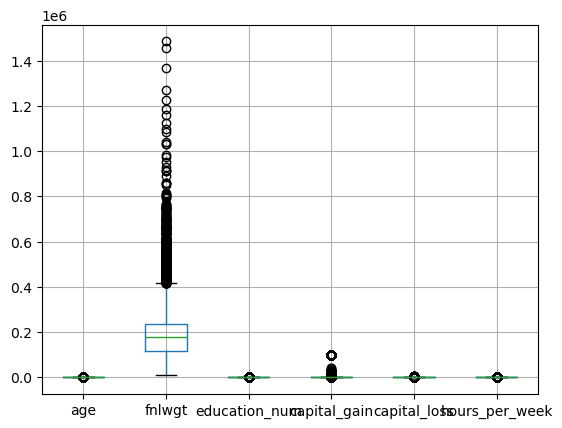

In [43]:
df.boxplot()
plt.show()

In [44]:
df=df.replace(r'^\s*\?\s*$', np.nan, regex=True)

In [45]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     582
income               0
dtype: int64

In [46]:
df.fillna({'workclass':df.workclass.mode()[0],
          'occupation':df.occupation.mode()[0],
          'native_country':df.native_country.mode()[0]},inplace=True)

In [47]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [48]:
#### removing outliers
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25) 
    Q3=df[column].quantile(0.75) 
    IQR=Q3-Q1 
    lower_extreme=Q1-1.5*IQR 
    upper_extreme=Q3+1.5*IQR 
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x> upper_extreme else x) 
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col) 

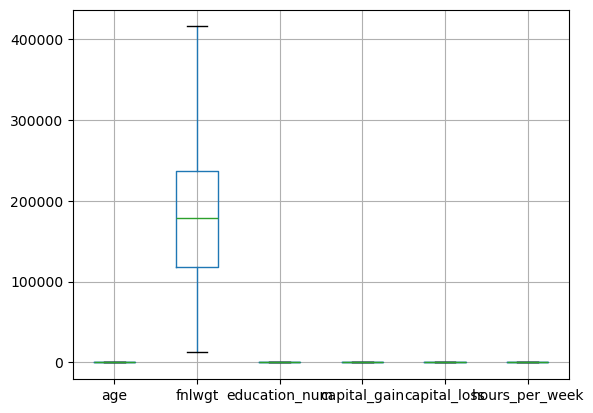

In [49]:
df.boxplot()
plt.show()

In [50]:
df['net_capital']=df['capital_gain']-df['capital_loss']

In [51]:
### new feature 2 is work_hours_category 
###  converts continuous hours_per_week into categorical buckets
df['work_hours_category'] = pd.cut(df['hours_per_week'],
                                   bins=[0, 20, 40, 60, 100],
                                   labels=['part_time', 'full_time', 'overtime', 'extreme'])

In [52]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,net_capital,work_hours_category
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K,0.0,full_time
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,32.5,United-States,<=50K,0.0,full_time
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K,0.0,full_time
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K,0.0,full_time
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K,0.0,full_time


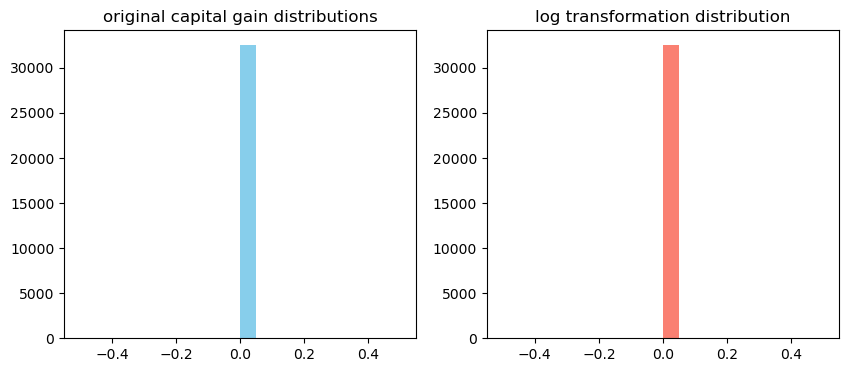

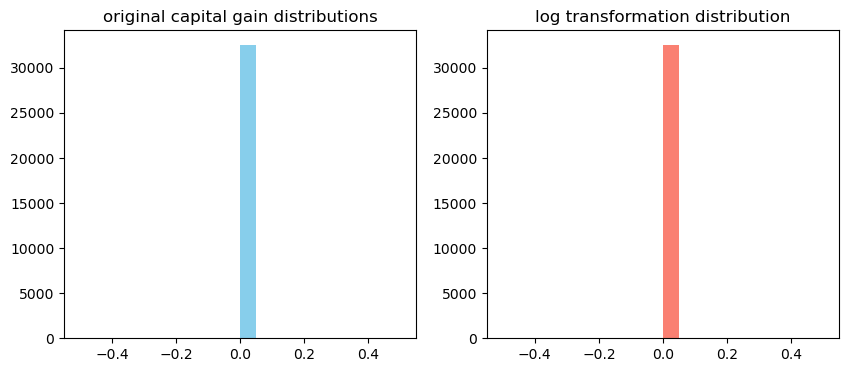

In [57]:
df['log_capital_gain']=np.log1p(df['capital_gain'])

### comparing distributions

fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].hist(df['capital_gain'],bins=20,color='skyblue')
axes[0].set_title('original capital gain distributions')

axes[1].hist(df['log_capital_gain'],bins=20,color='salmon')
axes[1].set_title('log transformation distribution')
plt.show()

In [58]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,net_capital,work_hours_category,log_capital_gain
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K,0.0,full_time,0.0
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,32.5,United-States,<=50K,0.0,full_time,0.0
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K,0.0,full_time,0.0
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K,0.0,full_time,0.0
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K,0.0,full_time,0.0
